# Scientific plotting for publication with OmicVerse

In this tutorial, we focus on a practical question: **how to make biologically accurate, visually consistent, and publication-ready figures when using `omicverse`**.

This is not only an API tutorial. We will explain **what to do**, **why to do it**, and **which mistakes to avoid** when generating figures for manuscripts, preprints, and reports.

The core principles are:

- figures should communicate biology before decoration
- the same biological category should keep the same color across figures
- panel size, font, resolution, and export format should be standardized early
- continuous and categorical variables should use different color logic
- final figures should be exported in both raster and vector formats whenever possible

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import omicverse as ov

# Optional: use a processed AnnData object from your own analysis.
# adata = ...

# OmicVerse provides convenient styling helpers.
ov.plot_set(font_path='Arial')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Start from a reproducible visual standard

The first step in scientific plotting is **not plotting**. It is defining a reproducible visual baseline.

Why this matters:

- If you tune font size and panel size manually for every figure, the entire manuscript becomes inconsistent.
- If you save one figure at low resolution and another at high resolution, journal assembly becomes painful.
- If you decide colors only at the end, you usually break consistency across embeddings, heatmaps, and spatial panels.

A good default for compact manuscript figures is:

- single panel: `figsize=(4, 4)` or `figsize=(3, 3)`
- dense matrix or large embedding: `figsize=(8, 8)`
- final export: `dpi=300`
- crop white margins: `bbox_inches='tight'`
- save both `png` and `svg`

In [2]:
adata=ov.datasets.pbmc8k()

🩸 Downloading PBMC 8k dataset
Using Stanford mirror for pbmc8k
⚠️ File ./data/pbmc8k.h5ad already exists
 Loading data from ./data/pbmc8k.h5ad
✅ Successfully loaded: 7750 cells × 20939 genes


In [3]:
def set_publication_style(fontsize=12):
    plt.rcParams['figure.dpi'] = 80
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['font.size'] = fontsize
    plt.rcParams['axes.labelsize'] = fontsize
    plt.rcParams['axes.titlesize'] = fontsize + 1
    plt.rcParams['xtick.labelsize'] = fontsize - 1
    plt.rcParams['ytick.labelsize'] = fontsize - 1
    plt.rcParams['legend.fontsize'] = fontsize - 1
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42


def save_figure_pair(stem):
    plt.savefig(f'{stem}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{stem}.svg')
    #plt.savefig(f'{stem}.pdf')


set_publication_style(fontsize=13)

The helper above is written out so you can see what it sets. `omicverse` has
the same thing built in, and using it means one style rather than two: the
plotting functions read these rcParams instead of carrying their own defaults.

`ov.pl.font_sizes()` reports what the current settings resolve to, and
`ov.pl.style_axes(ax)` applies the frame convention the rest of `ov.pl` uses —
top and right spines hidden, the other two offset outward by 10 points.

In [4]:
ov.plot_set(fontsize=13)
ov.pl.font_sizes()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0
✅ plot_set complete.



{'label': 13.0, 'tick': 13.0, 'title': 13.0, 'legend': 11.96}

In [5]:
# rc_context here only so the notebook does not reprint the whole banner;
# in a script you would just call ov.plot_set(fontsize=...) once.
for size in (9, 13, 18):
    with plt.rc_context({'axes.labelsize': size, 'axes.titlesize': size + 2}):
        print(f"plot_set(fontsize={size:>2}) -> label {ov.pl.font_size(None, 'label'):>4.1f}"
              f"   title {ov.pl.font_size(None, 'title'):>4.1f}")

plot_set(fontsize= 9) -> label  9.0   title 11.0
plot_set(fontsize=13) -> label 13.0   title 15.0
plot_set(fontsize=18) -> label 18.0   title 20.0


left spine: ('outward', 10.0)


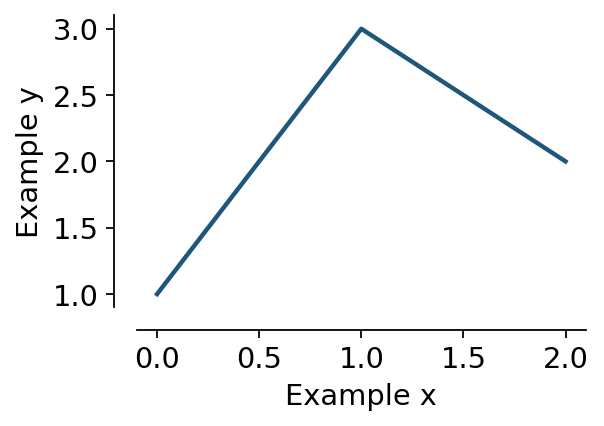

In [6]:
fig, ax = plt.subplots(figsize=(3.6, 2.4))
ax.plot([0, 1, 2], [1, 3, 2], lw=2)
ax.set_xlabel('Example x'); ax.set_ylabel('Example y')
ov.pl.style_axes(ax)
print("left spine:", ax.spines['left'].get_position())
plt.show()

## 2. Separate categorical color design from continuous color design

A common mistake is to use the same color logic for all figures.

This is incorrect because:

- **categorical annotations** such as cell types, clusters, niches, and samples require **stable named colors**
- **continuous values** such as scores, abundance, logFC, or expression require **ordered colormaps**

Purpose of this step:

- make the reader recognize the same biology instantly across multiple figures
- prevent visual misinterpretation caused by arbitrary remapping
- improve comparability between panels

Recommended rules:

- for cell types or clusters: build a dictionary once and reuse it everywhere
- for abundance-like values: start with `Reds`
- for signed effects such as enrichment or log fold change: start with `RdBu_r`

In [7]:
# Example: stable categorical palette.
# Replace 'cell_type' with your own annotation column.

if 'cell_type' in getattr(adata, 'obs', {}):
    categories = list(adata.obs['cell_type'].astype('category').cat.categories)
    palette = ov.pl.sc_color[8:] + ov.pl.red_color + ov.pl.orange_color + ov.pl.sc_color
    color_dict = {k: palette[i] for i, k in enumerate(categories)}
else:
    color_dict = {
        'T cell': '#279AD7',
        'B cell': '#F0A202',
        'Myeloid': '#E45756',
        'Stromal': '#54A24B',
    }

# Example: continuous colormap choices.
seq_cmap = 'Reds'      # abundance, score, density, expression intensity
signed_cmap = 'RdBu_r' # up/down, positive/negative, centered contrasts

## 3. Make embeddings readable before making them beautiful

UMAP, MDE, t-SNE, and spatial embeddings are often the first figures people see. Their purpose is usually **overview and orientation**, not decoration.

What this step should achieve:

- show the major biological structure clearly
- preserve category identity with stable colors
- remove unnecessary visual clutter

Good practice:

- use a compact square panel
- keep point size moderate
- remove oversized legends inside dense panels
- avoid changing palette order across figures
- use the same `basis` and annotation names consistently throughout the tutorial or manuscript

In [8]:
adata

AnnData object with n_obs × n_vars = 7750 × 20939
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    obsm: 'UMAP', 'X_pca', 'X_umap'

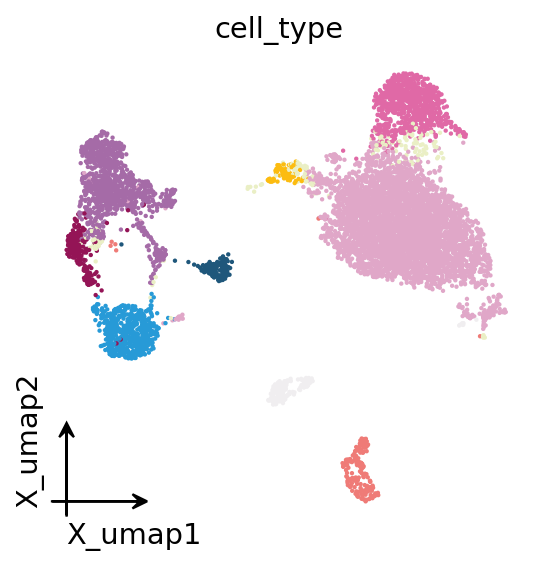

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


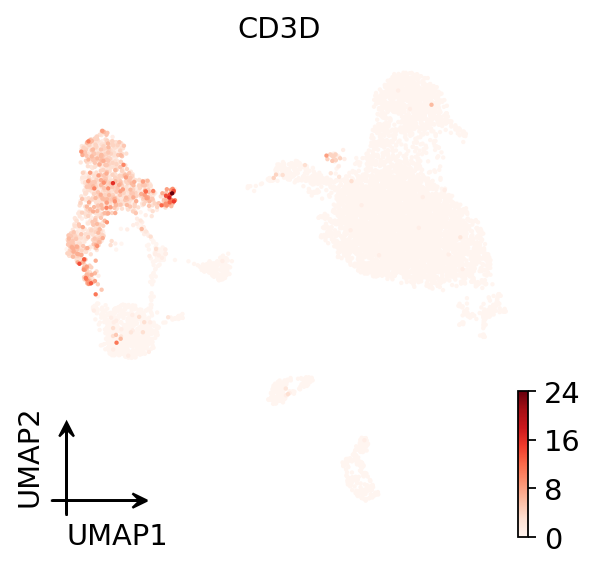

In [9]:
# Categorical embedding
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='cell_type',
    #palette=color_dict,
    frameon='small',
    legend_loc=None,
    show=False,
    ax=ax,
)
save_figure_pair('figures/plotting/embedding_celltype')
plt.show()

# Continuous embedding
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.umap(
    adata,
    color='CD3D',
    cmap='Reds',
    frameon='small',
    show=False,
    ax=ax,
)
save_figure_pair('figures/plotting/embedding_module_score')
plt.show()

## 4. Use dotplots and violins to answer specific biological questions

Embeddings are useful for overview, but they are weak for exact comparison. When you need to compare **marker intensity**, **signature activity**, or **group differences**, use summary plots.

Why this step matters:

- dotplots compress many genes and groups into a readable panel
- violin plots expose distribution shape instead of only mean signal
- these plots provide stronger support for biological interpretation than embeddings alone

The goal is not to show more genes. The goal is to show the **right genes** with a **clear group order**.

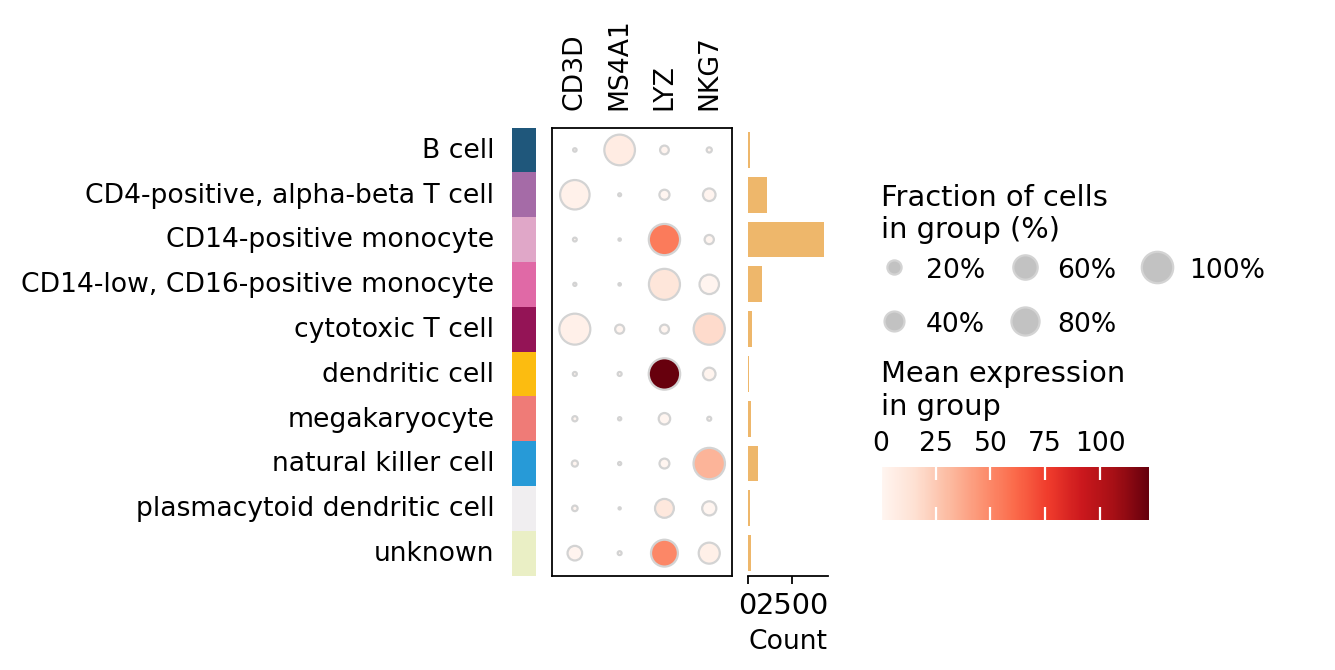

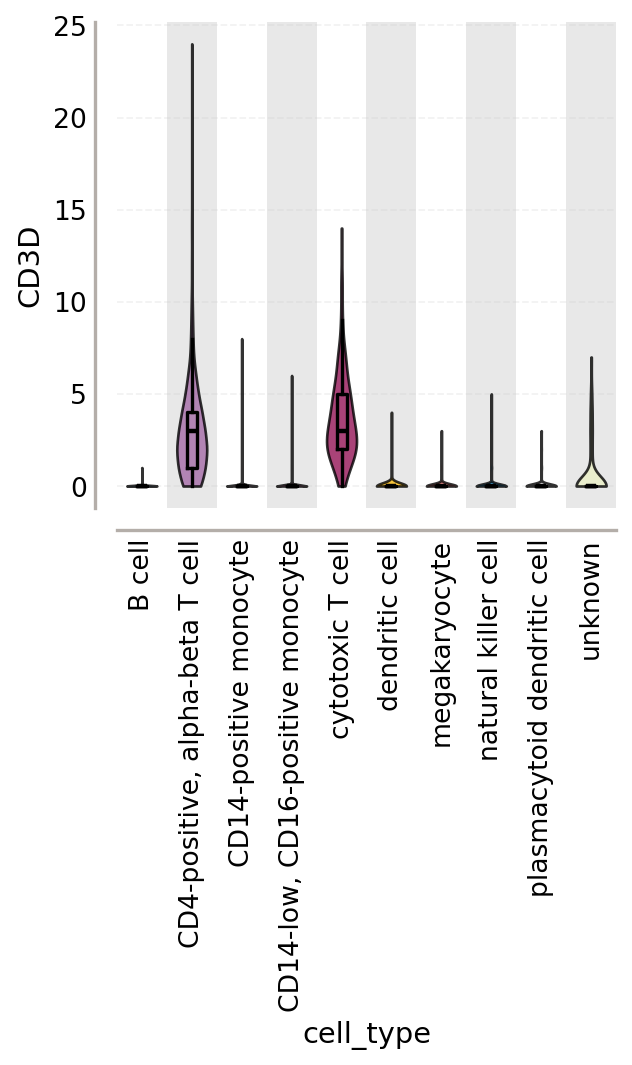

In [10]:
marker_genes = ['CD3D', 'MS4A1', 'LYZ', 'NKG7']

ov.pl.dotplot(
    adata,
    marker_genes,
    groupby='cell_type',
    cmap='Reds',
    figsize=(4, 4),
    show=False,
)
save_figure_pair('figures/plotting/dotplot_markers')
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.violin(
    adata,
    keys=['CD3D'],
    groupby='cell_type',
    rotation=90,
    stripplot=False,
    show=False,
    ax=ax,
    add_box=True
)
save_figure_pair('figures/plotting/violin_module_score')
plt.show()

## 5. Heatmaps should emphasize structure, not complexity

Heatmaps are powerful because they reveal coordinated patterns across groups. They are also easy to overcomplicate.

Purpose of this step:

- summarize structured differences across cell states, niches, or pathways
- make trends visible at a glance
- keep group-level interpretation readable

Recommended practice:

- cluster only when clustering adds information
- use diverging colormaps for centered values and sequential colormaps for abundance
- keep labels readable before increasing matrix size

In [11]:
# Example matrix: rows are categories, columns are features/pathways.
# Replace with your own summary matrix.
# matrix = ...

# sns.clustermap(
#     matrix,
#     cmap='RdBu_r',
#     figsize=(8, 8),
#     center=0,
# )
# plt.savefig('figures/plotting/heatmap_signed.png', dpi=300, bbox_inches='tight')
# plt.savefig('figures/plotting/heatmap_signed.svg', dpi=300, bbox_inches='tight')

## 6. Spatial plots should preserve tissue context while remaining interpretable

When plotting spatial transcriptomics or CosMx-style segmentation results, you should treat the image background as **context**, not as the main message.

Why this step matters:

- too much segmentation detail hides biology
- too much biological overlay hides tissue structure
- readers should be able to see both location and pattern without visual overload

Practical rules:

- keep panel shape close to square when possible
- use compact layouts such as `(4, 4)` for a single field of view
- keep contour lines and overlays visually subordinate
- reuse the same category colors used in embeddings and summary plots

In [12]:
# Template for segmented spatial plotting — omicverse has this natively,
# so no squidpy import is needed. Adjust the keys to your own AnnData;
# pbmc8k has no spatial coordinates, so this stays a template here.

# ov.pl.spatial_segment(
#     adata,
#     seg_cell_id='cell_ID',
#     color='cell_type',
#     library_key='fov',
#     library_id='1',
#     palette=color_dict,
#     img=False,
#     figsize=(4, 4),
#     legend_loc=None,
#     frameon='small',
#     show=False,
# )
# save_figure_pair('figures/plotting/spatial_segment_celltype')

# For a cell-boundary overlay coloured by a second variable, see
# ov.pl.spatial_segment_overlay; for polygon-based segmentation masks,
# ov.pl.spatialseg.

## 7. Export for both analysis and publication

Export is not a cosmetic afterthought. It determines whether your figure survives manuscript preparation.

Why save both formats:

- `png` is convenient for quick inspection, slides, and raster-based submissions
- `svg` is better for vector editing, journal layout, and text sharpness

Why `dpi=300` matters:

- below this, labels and small symbols often degrade in print or PDF assembly

Why `bbox_inches='tight'` matters:

- unnecessary margins complicate multi-panel composition

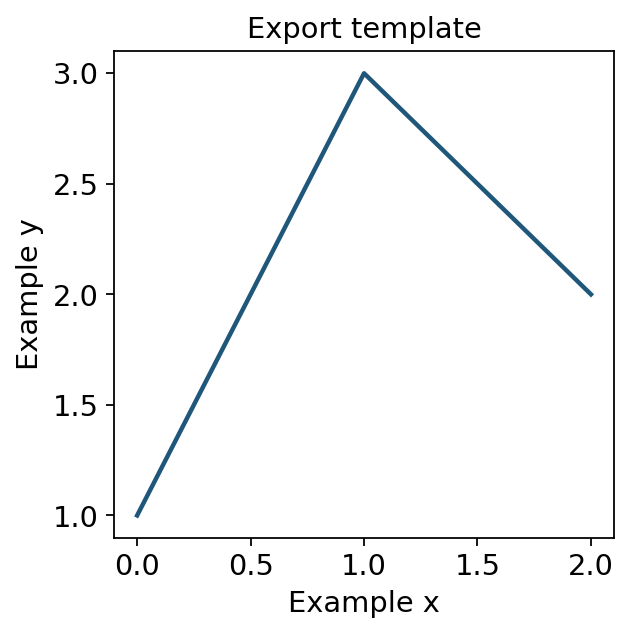

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 1, 2], [1, 3, 2], lw=2)
ax.set_xlabel('Example x')
ax.set_ylabel('Example y')
ax.set_title('Export template')
save_figure_pair('figures/plotting/export_template')
plt.show()

## 8. Assemble the panels — `ov.pl.multipanel`

Everything so far produced *one* plot at a time. A manuscript figure is a
**composition**: several panels, at a width the journal specified, with `a` /
`b` / `c` tags in the margin, exported once.

Doing that by hand means `plt.subplots` plus `gridspec` plus a hand-placed
`ax.text` per panel, and the tags drift the moment the figure is resized
because they are positioned in axes fractions. `ov.pl.multipanel` builds the
grid, tags the panels in reading order, and returns the axes **keyed by the
letter printed on them** — so a panel is referred to by what the reader sees.

Three things it does that a bare `plt.subplots` does not:

- **physical width**, in mm / cm / inches / pixels, or by journal preset —
  `width='nature-double'` is exactly 183 mm
- **tags offset in typographic points**, not axes fractions, so the same
  offset looks identical on a 40 mm and a 180 mm panel
- **mosaic layouts**, where a panel spans several cells

Panels come back in a dict, so filling them is a loop or a lookup.

figure size: [89. 75.] mm
panel keys : ['a', 'b', 'c', 'd']


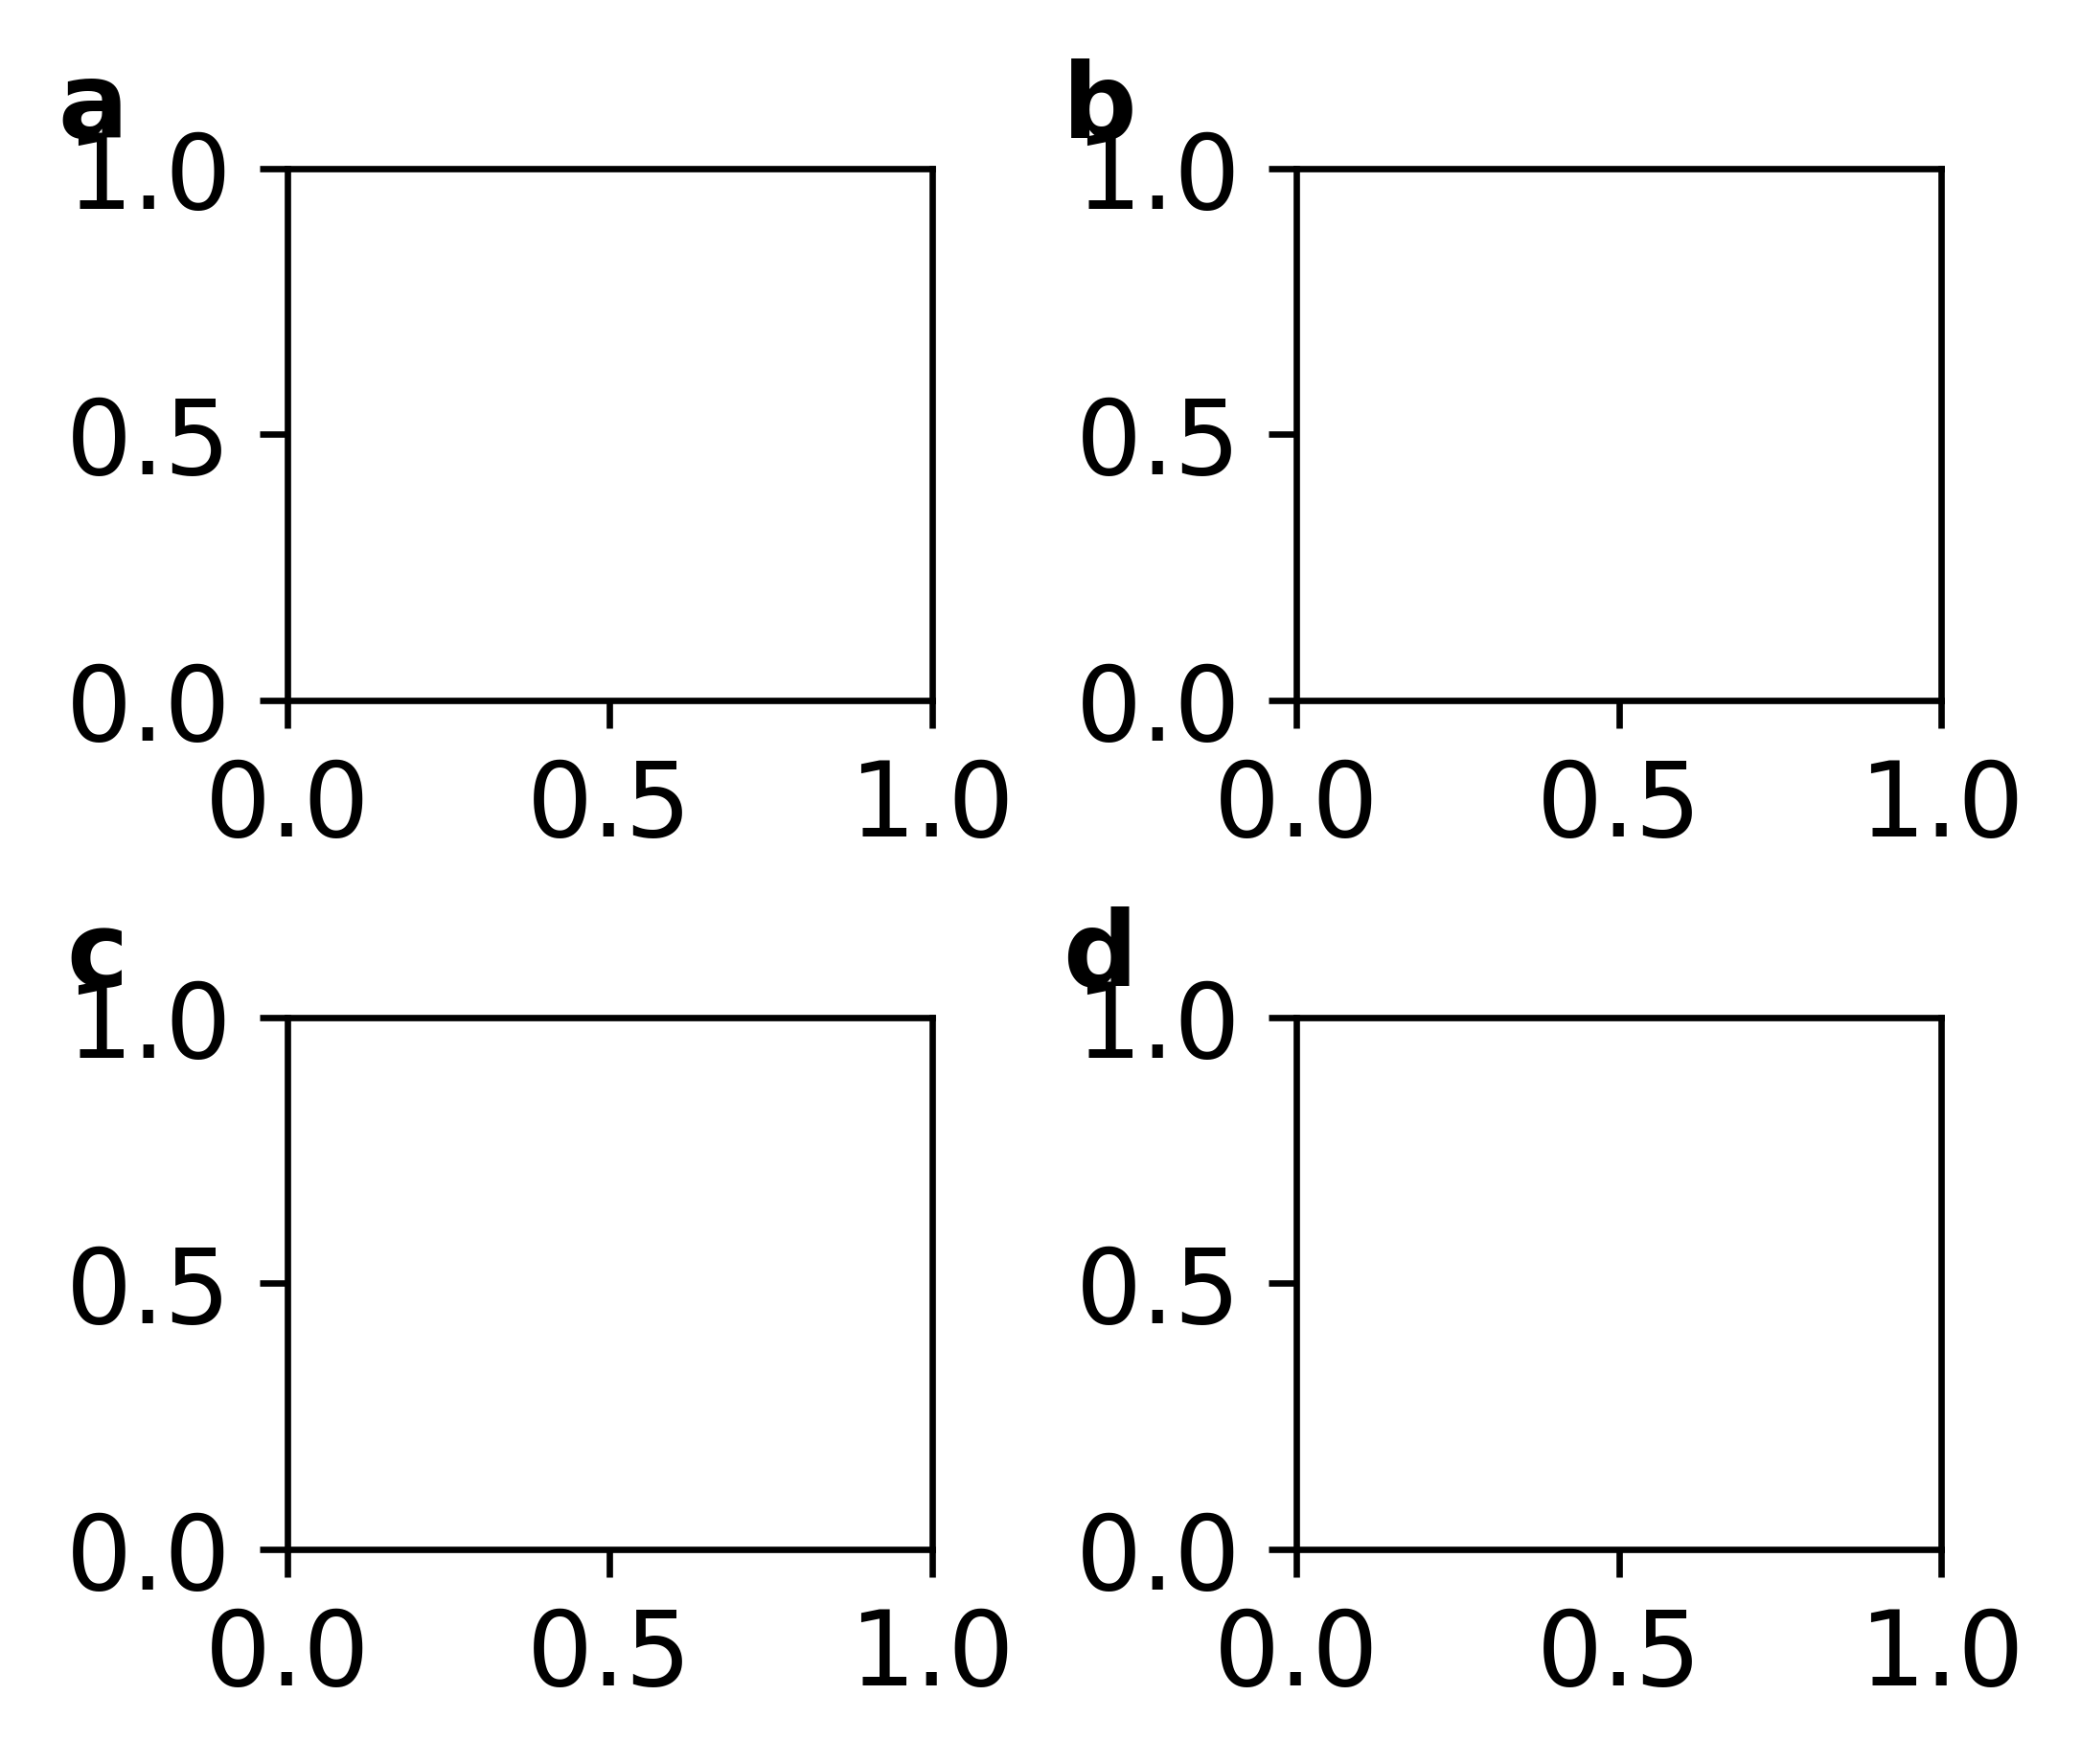

In [14]:
fig, axes = ov.pl.multipanel((2, 2), width='nature-single', height=75)
print('figure size:', (fig.get_size_inches() * 25.4).round(1), 'mm')
print('panel keys :', list(axes))

### A 2 x 2 grid

The showcase layout: four panels, equal size, tagged `a`-`d` in reading
order. Nothing is placed by hand.

In [15]:
# Short display names for the ontology labels, so tick labels stay readable.
SHORT = {
    'CD14-positive monocyte': 'CD14 Mono',
    'CD14-low, CD16-positive monocyte': 'CD16 Mono',
    'CD4-positive, alpha-beta T cell': 'CD4 T',
    'cytotoxic T cell': 'CD8 T',
    'natural killer cell': 'NK',
    'B cell': 'B',
    'plasmacytoid dendritic cell': 'pDC',
    'dendritic cell': 'DC',
    'megakaryocyte': 'Mk',
}

In [16]:
frame = pd.DataFrame({
    'cell_type': adata.obs['cell_type'].map(SHORT).astype(str).to_numpy(),
    'n_genes': np.asarray((adata.X > 0).sum(axis=1)).ravel().astype(float),
    'CD3D': np.log1p(ov.pl.get_values(adata, 'CD3D')),
    'NKG7': np.log1p(ov.pl.get_values(adata, 'NKG7')),
}, index=adata.obs_names)
main = frame[frame['cell_type'] != 'nan']
print(main.shape, '|', main['cell_type'].nunique(), 'labelled types')
main.head(3).round(2)

(7557, 4) | 9 labelled types


,cell_type,n_genes,CD3D,NKG7
TGAGCCGTCGATAGAA-1_10X_5-rep1,CD14 Mono,2208.0,0.0,0.0
TACACGACAGGACGTA-1_10X_5-rep1,CD14 Mono,1828.0,0.0,0.0
GAAGCAGCAGCTGTGC-1_10X_5-rep1,CD14 Mono,2822.0,0.0,0.0


pieplot: merged 4 categories below 3% into 'other': B, DC, Mk, pDC


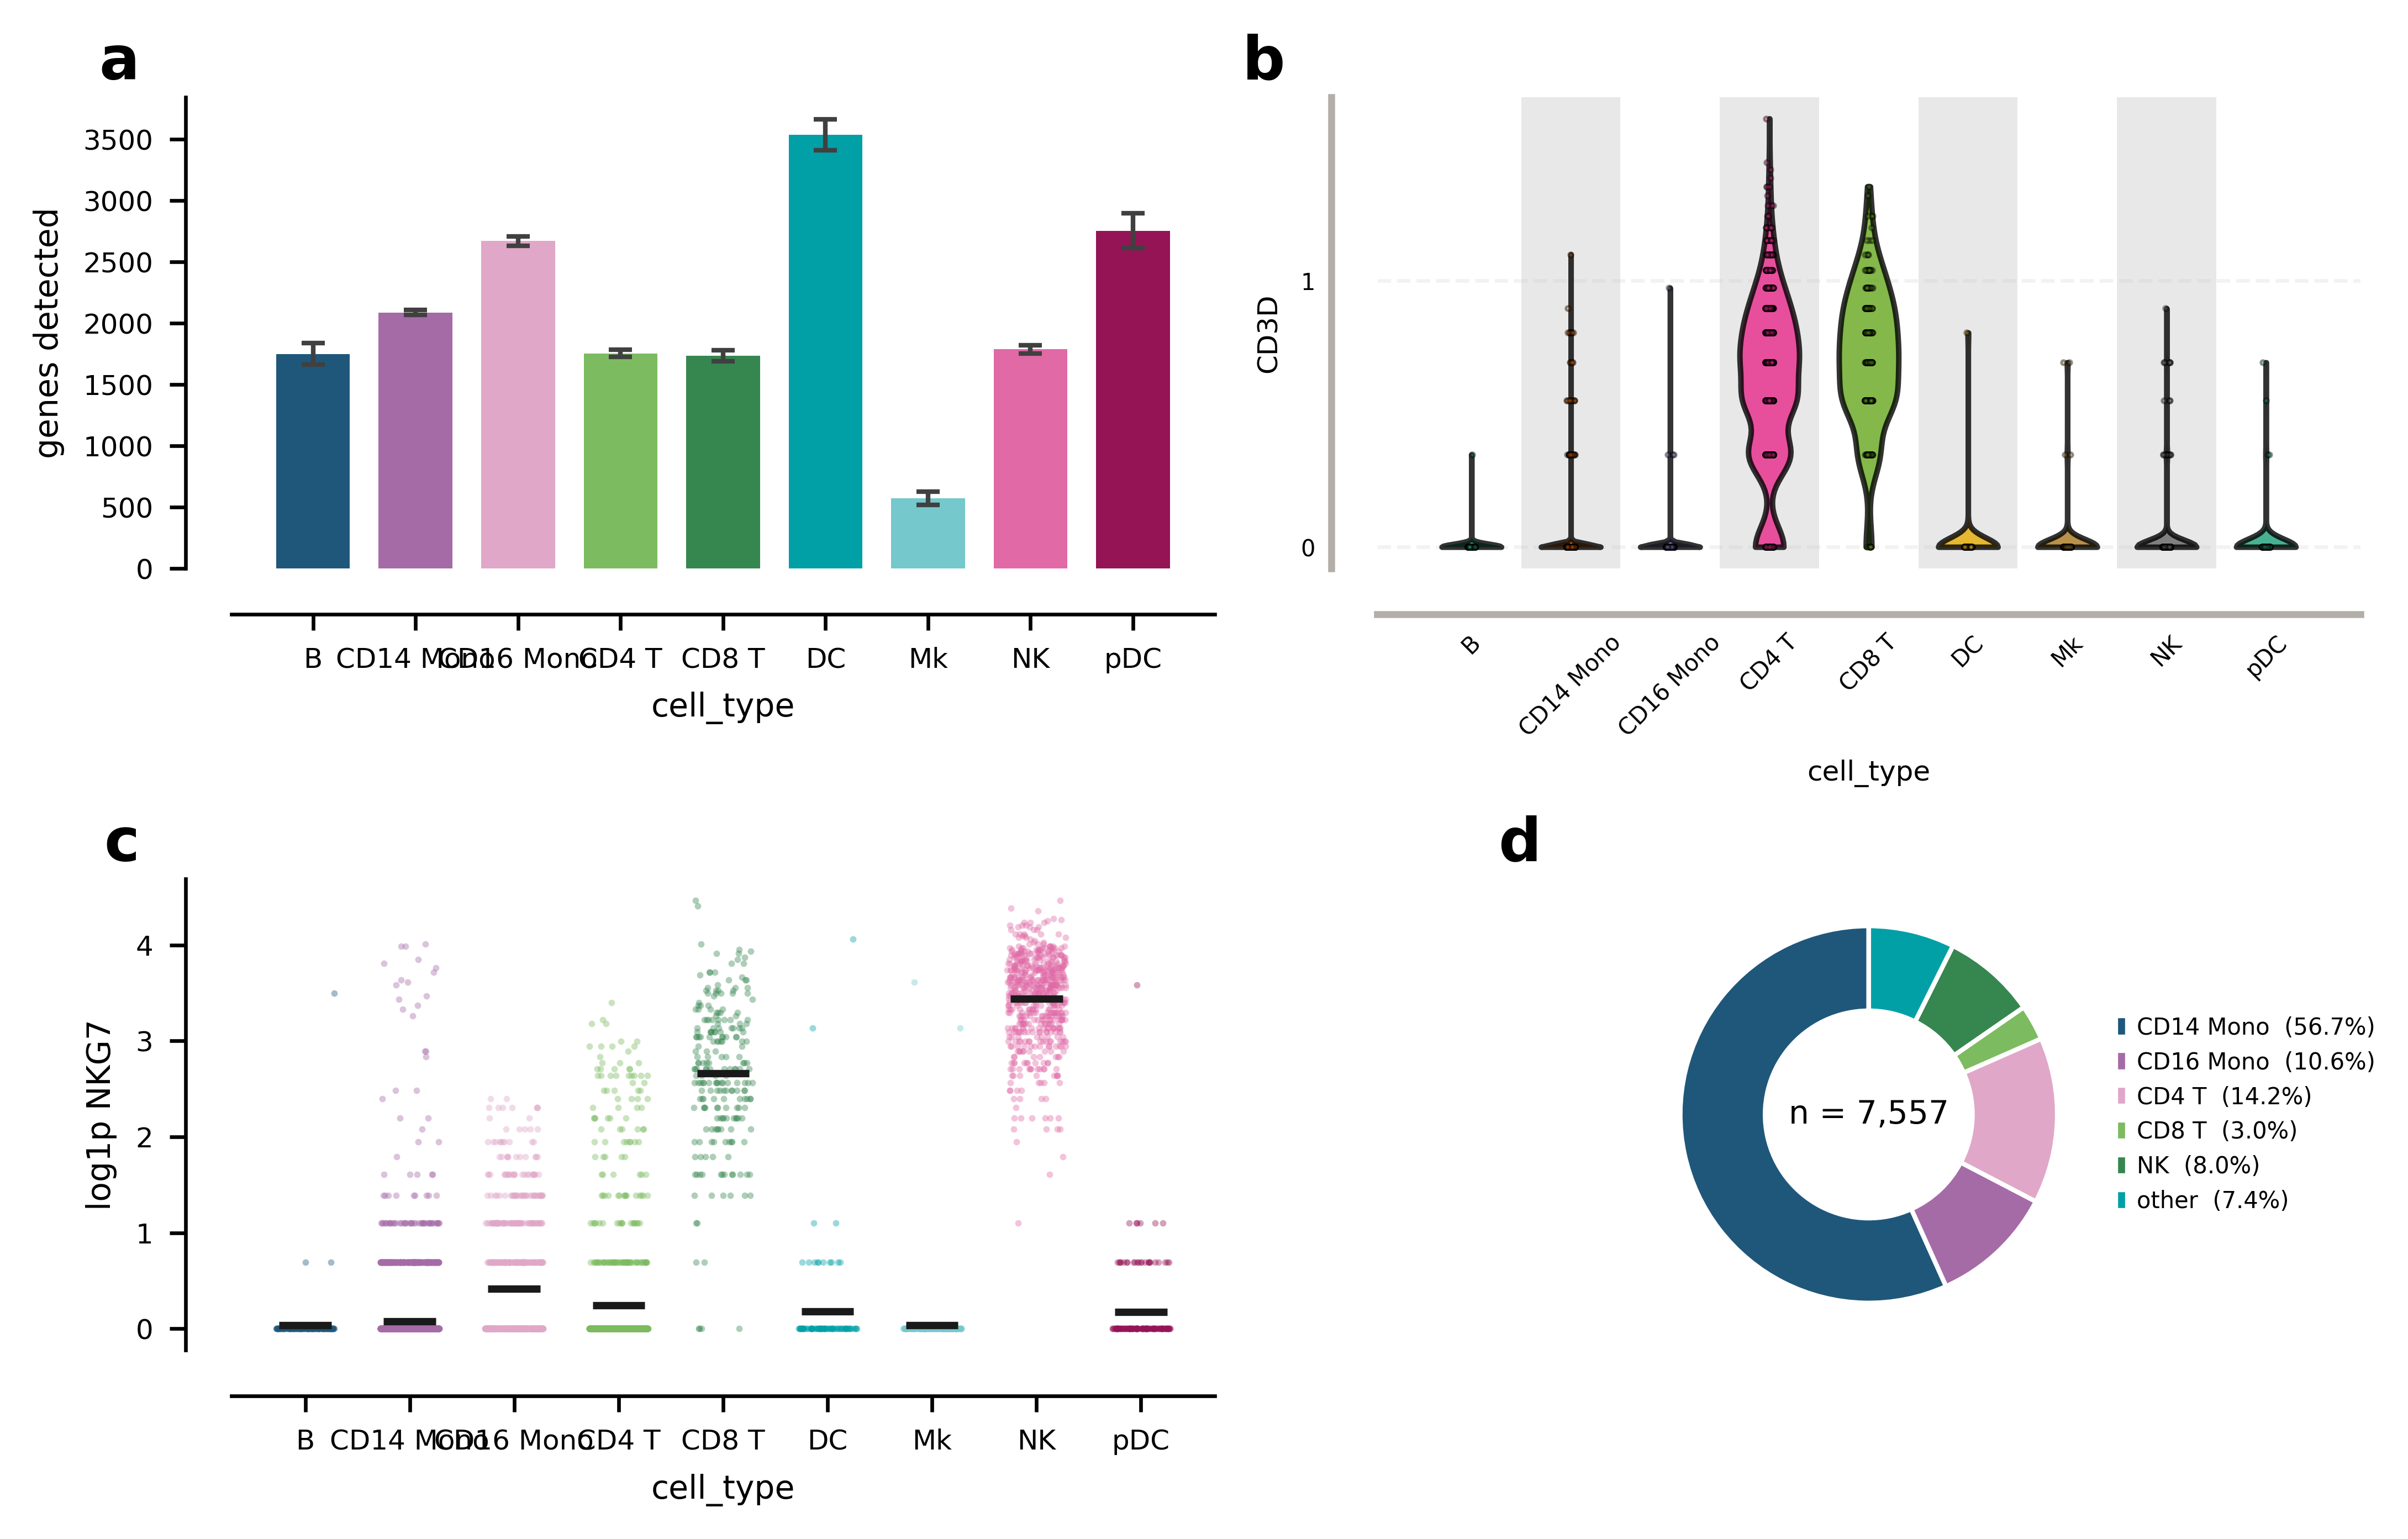

In [17]:
fig, ax = ov.pl.multipanel((2, 2), width='nature-double', height=115)
ov.pl.barplot(main, 'cell_type', 'n_genes', ax=ax['a'], rotation=45, fontsize=6,
              errorbar='ci', ylabel='genes detected')
ov.pl.violin(main, keys='CD3D', groupby='cell_type', ax=ax['b'], rotation=45, fontsize=6,
                 ylabel='log1p CD3D')
ov.pl.stripplot(main, 'cell_type', 'NKG7', ax=ax['c'], rotation=45, fontsize=6,
                size=2, jitter=0.28, alpha=0.4, ylabel='log1p NKG7')
ov.pl.donutplot(main, 'cell_type', ax=ax['d'], fontsize=5, legend=True,
                other_threshold=0.03)
plt.show()

### A 1 x 3 row, each panel titled

A row is the layout for "three views of the same thing". `label='A'` switches
to uppercase tags, which some journals require.

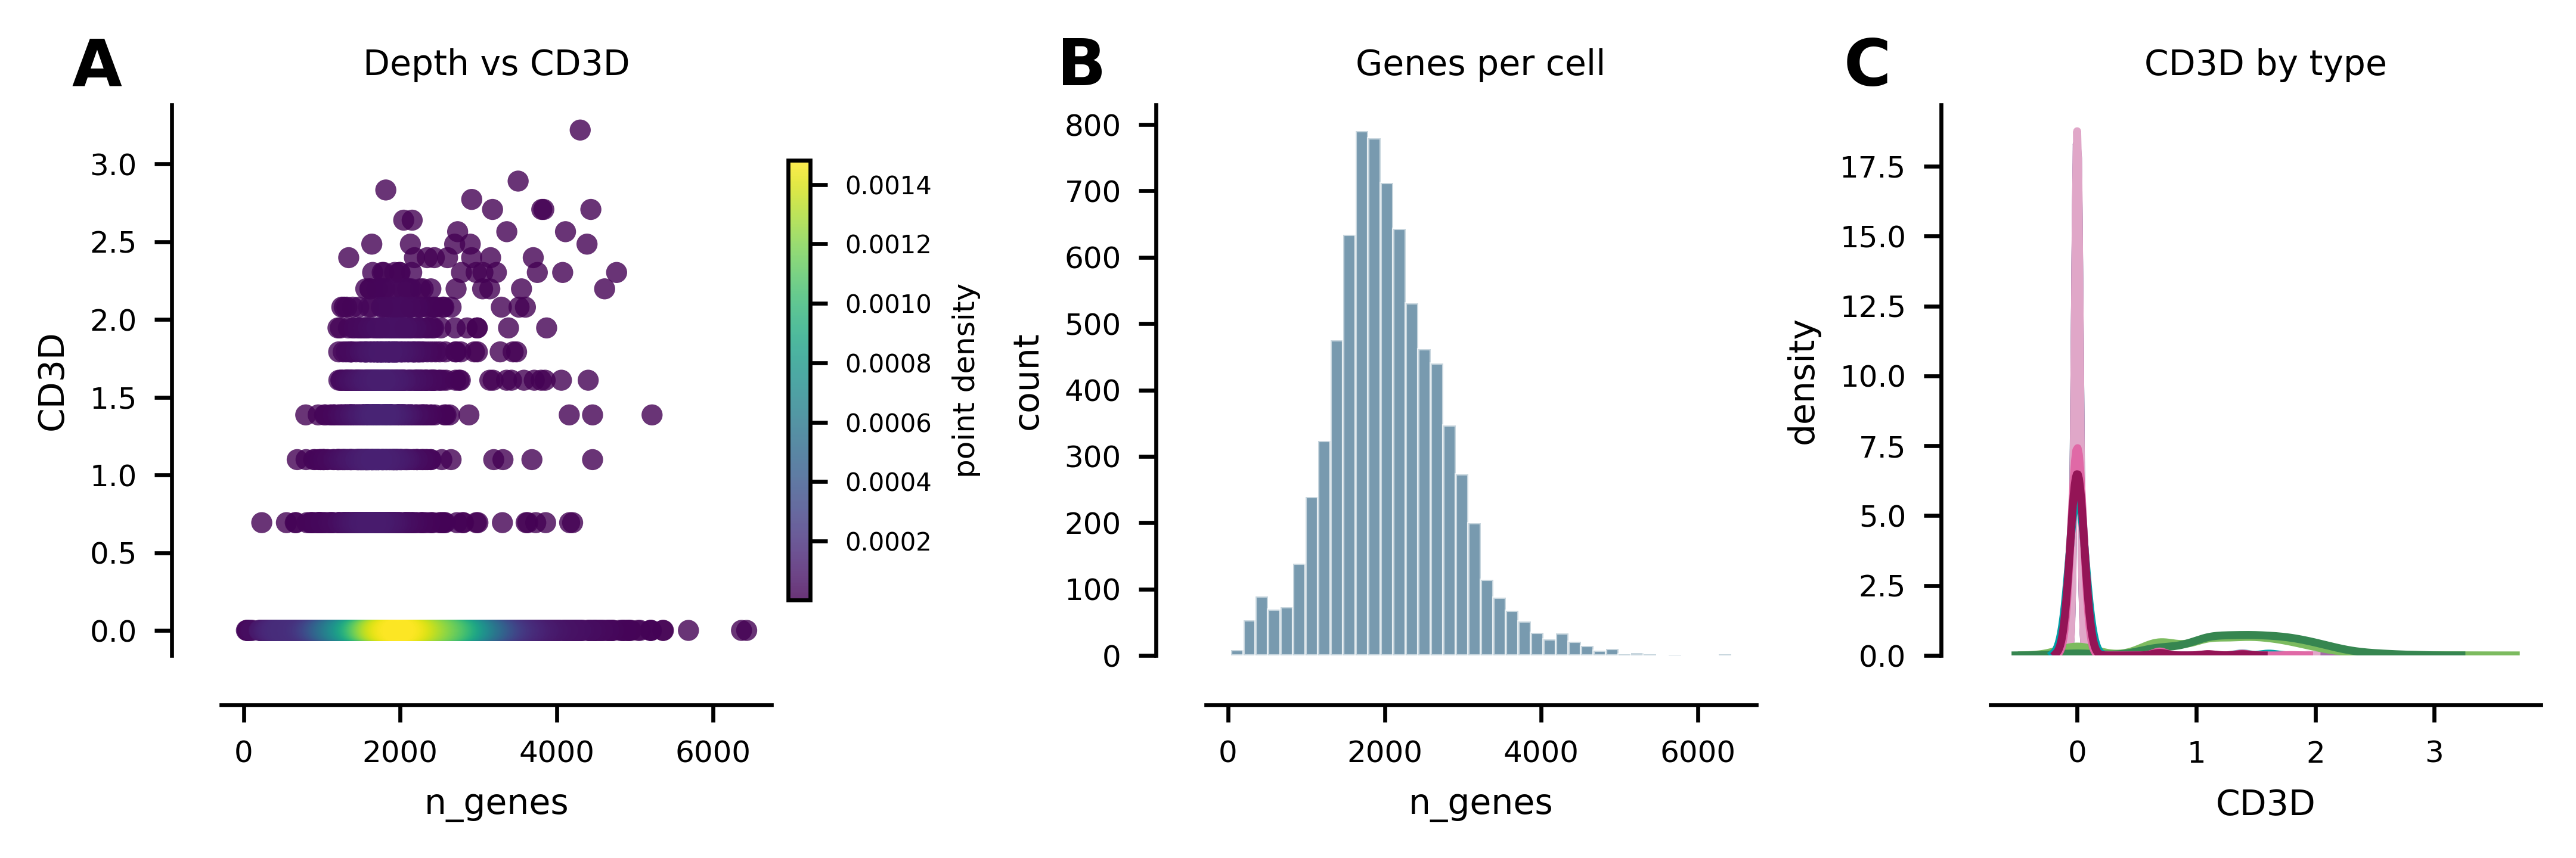

In [18]:
fig, ax = ov.pl.multipanel((1, 3), width=180, height=58, label='A')
ov.pl.scatterplot(frame, 'n_genes', 'CD3D', density=True, ax=ax['A'], fontsize=6)
ov.pl.histplot(frame, 'n_genes', bins=40, ax=ax['B'], fontsize=6)
ov.pl.kdeplot(main, 'CD3D', hue='cell_type', ax=ax['C'], fontsize=6, legend=False)
for key, title in zip('ABC', ('Depth vs CD3D', 'Genes per cell', 'CD3D by type')):
    ax[key].set_title(title, fontsize=7)
plt.show()

### Unequal panels

Real figures rarely divide evenly. `width_ratios` and `height_ratios` size the
tracks; a mosaic string lets a panel **span** cells, with `.` leaving a gap.

`'AAB'` / `'CDB'` reads exactly as it looks: `A` spans the top-left two cells,
`B` spans the full height on the right, `C` and `D` sit underneath `A`.

Panels are reachable by the mosaic key **or** by the tag printed on them, so
`ax['A']` and `ax['a']` are the same axes here.

Note what panel **a** shows once `lineplot` is given a binned x: CD3D in CD4 T
cells climbs steadily with sequencing depth, while the non-T populations stay
flat at zero. That is a depth artefact, not biology — the kind of thing a
per-cell scatter hides and an aggregated trend with a confidence band makes
obvious.

pieplot: merged 5 categories below 5% into 'other': B, CD8 T, DC, Mk, pDC


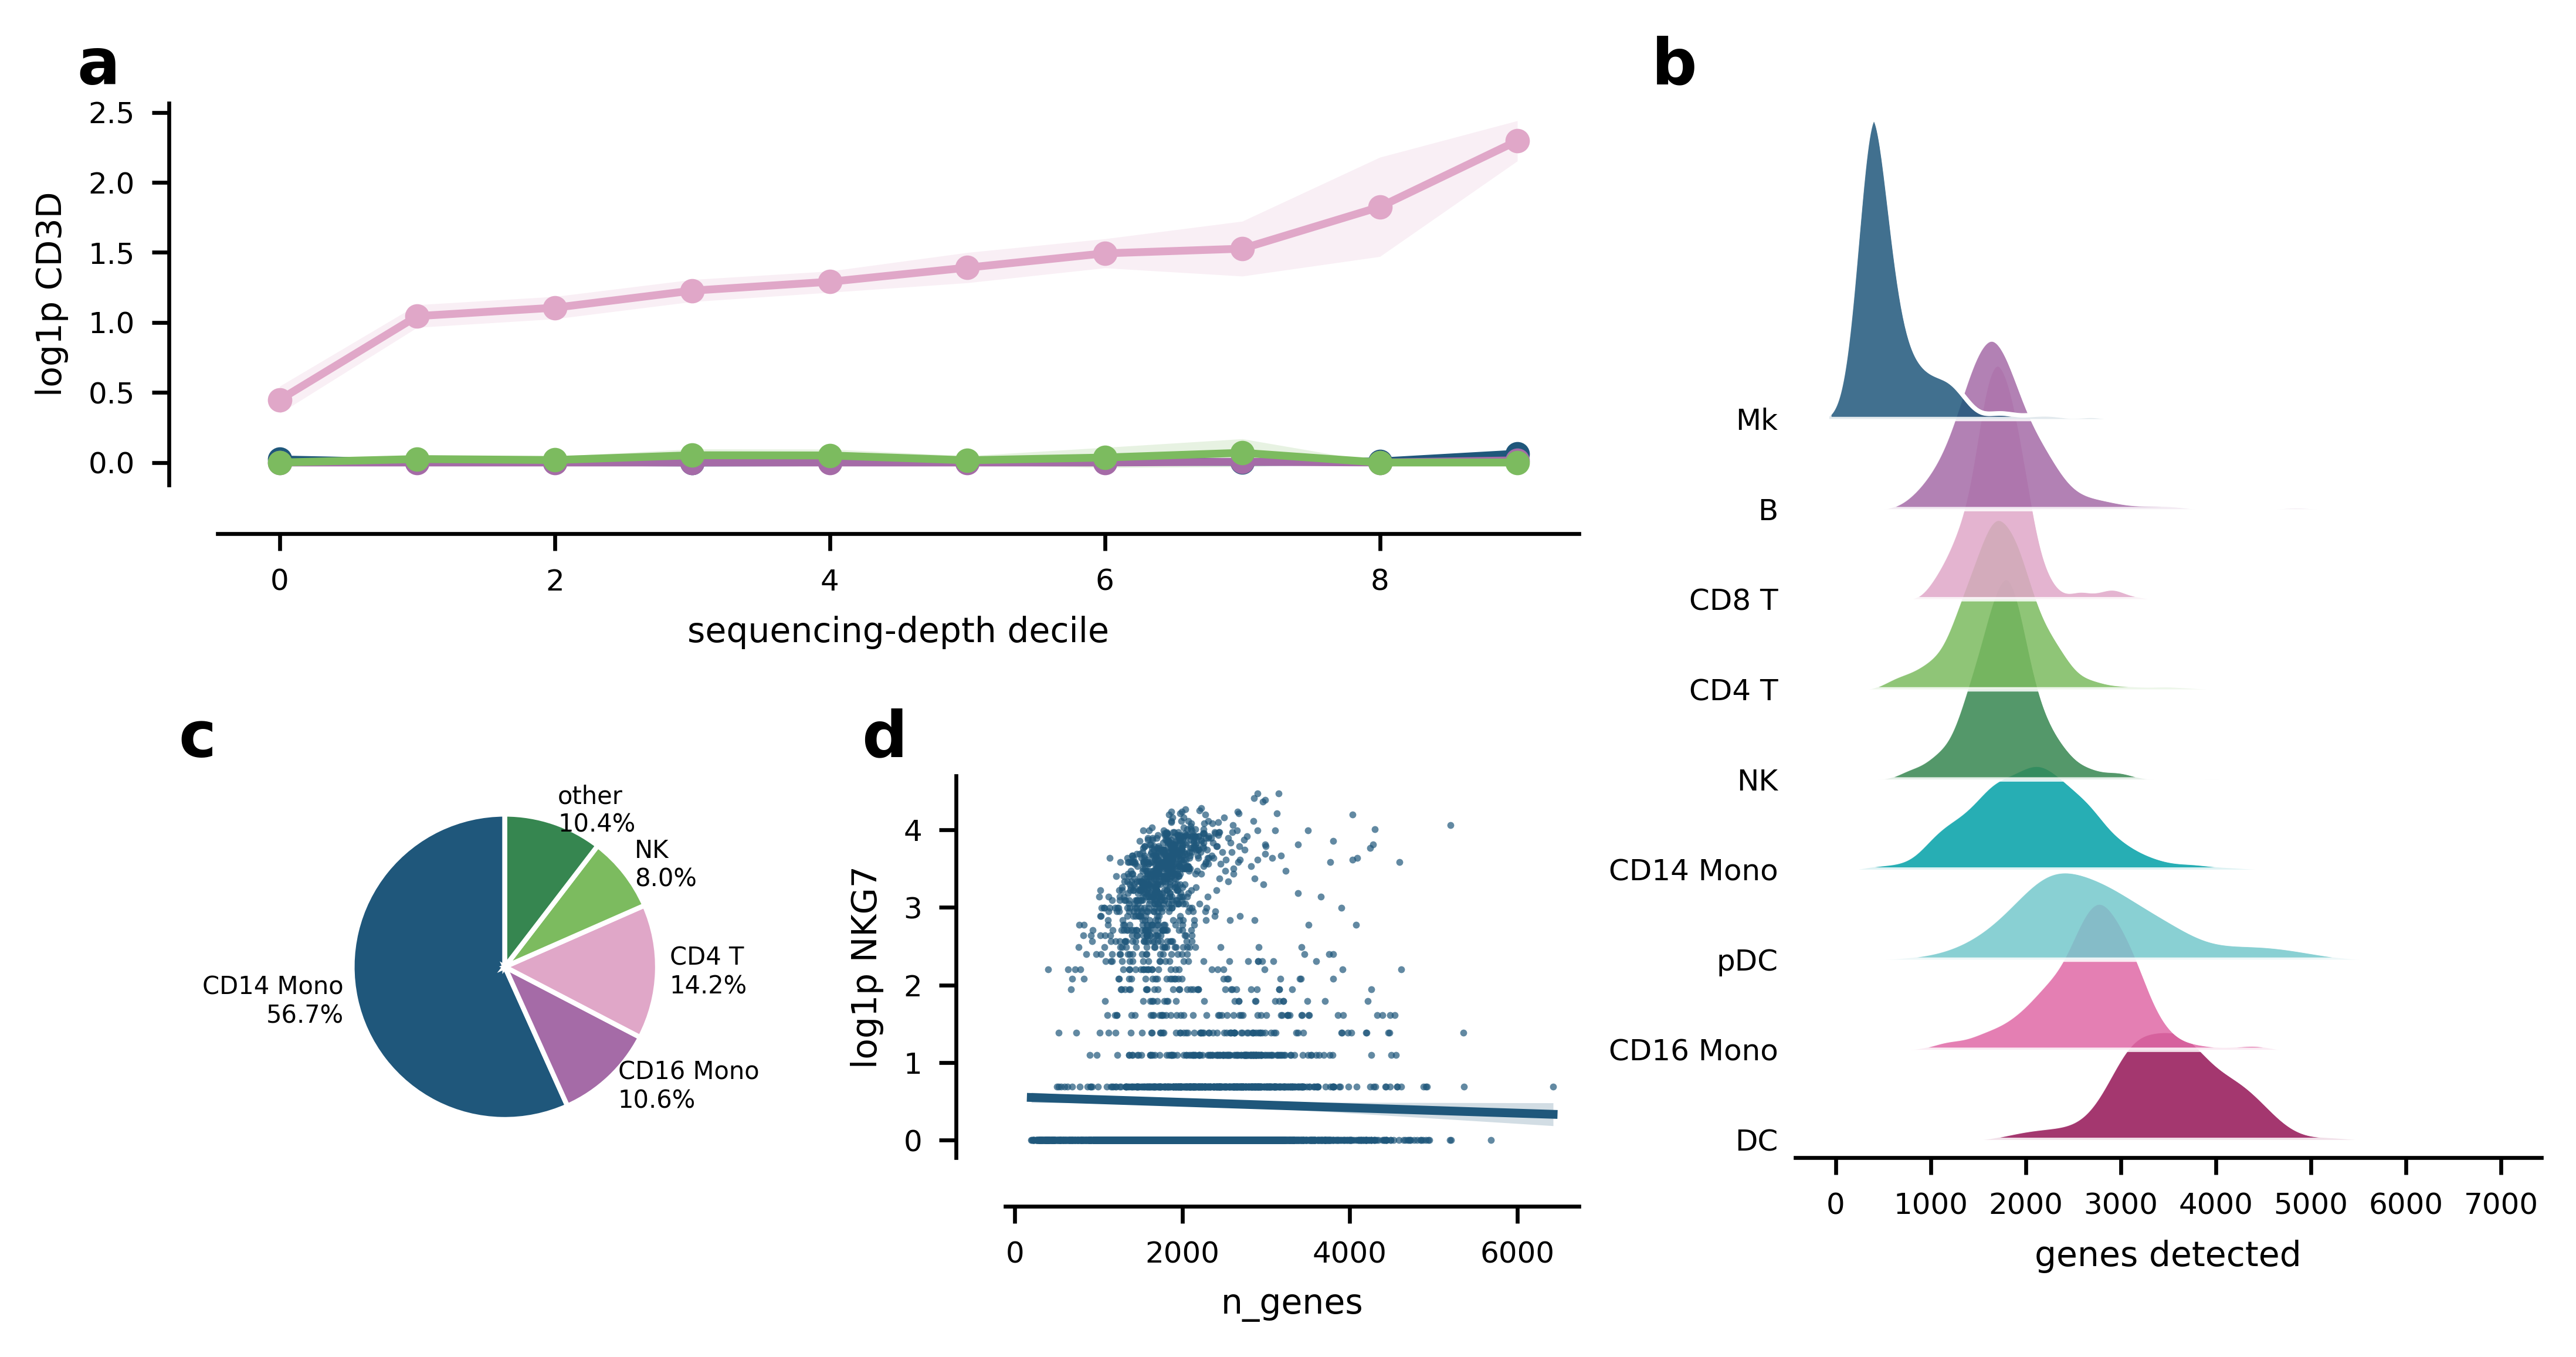

In [19]:
# lineplot aggregates repeated measurements at each x, so give it a binned x
# rather than one point per cell — here, sequencing-depth deciles.
trend = main.copy()
trend['depth_decile'] = pd.qcut(trend['n_genes'], 10, labels=False)
big = trend['cell_type'].value_counts().head(4).index
trend = trend[trend['cell_type'].isin(big)]

fig, ax = ov.pl.multipanel('AAB\nCDB', width='nature-double', height=95,
                           width_ratios=[1, 1, 1.3], label='a')
ov.pl.lineplot(trend, 'depth_decile', 'CD3D', hue='cell_type', ax=ax['A'],
               errorbar='ci', markers=True, fontsize=6, legend=False,
               xlabel='sequencing-depth decile', ylabel='log1p CD3D')
ov.pl.ridgeplot(main, 'n_genes', 'cell_type', ax=ax['B'], fontsize=6,
                overlap=0.7, xlabel='genes detected')
ov.pl.pieplot(main, 'cell_type', ax=ax['C'], fontsize=5,
              label_style='percent', other_threshold=0.05)
ov.pl.regplot(main, 'n_genes', 'NKG7', ax=ax['D'], fontsize=6, s=2,
              annotate=False, ylabel='log1p NKG7')
plt.show()

### Tagging a panel yourself

`ov.pl.add_panel_label` places a single tag, offset from the axes corner in
**points**. That is the difference from the usual `ax.text(-0.1, 1.05, 'a')`
idiom: at 40 mm the axes-fraction version sits on top of the y-label, and at
180 mm it floats away. The point offset does neither.

`ov.pl.take_legend_out` moves a legend clear of the data instead of shrinking
it into a corner.

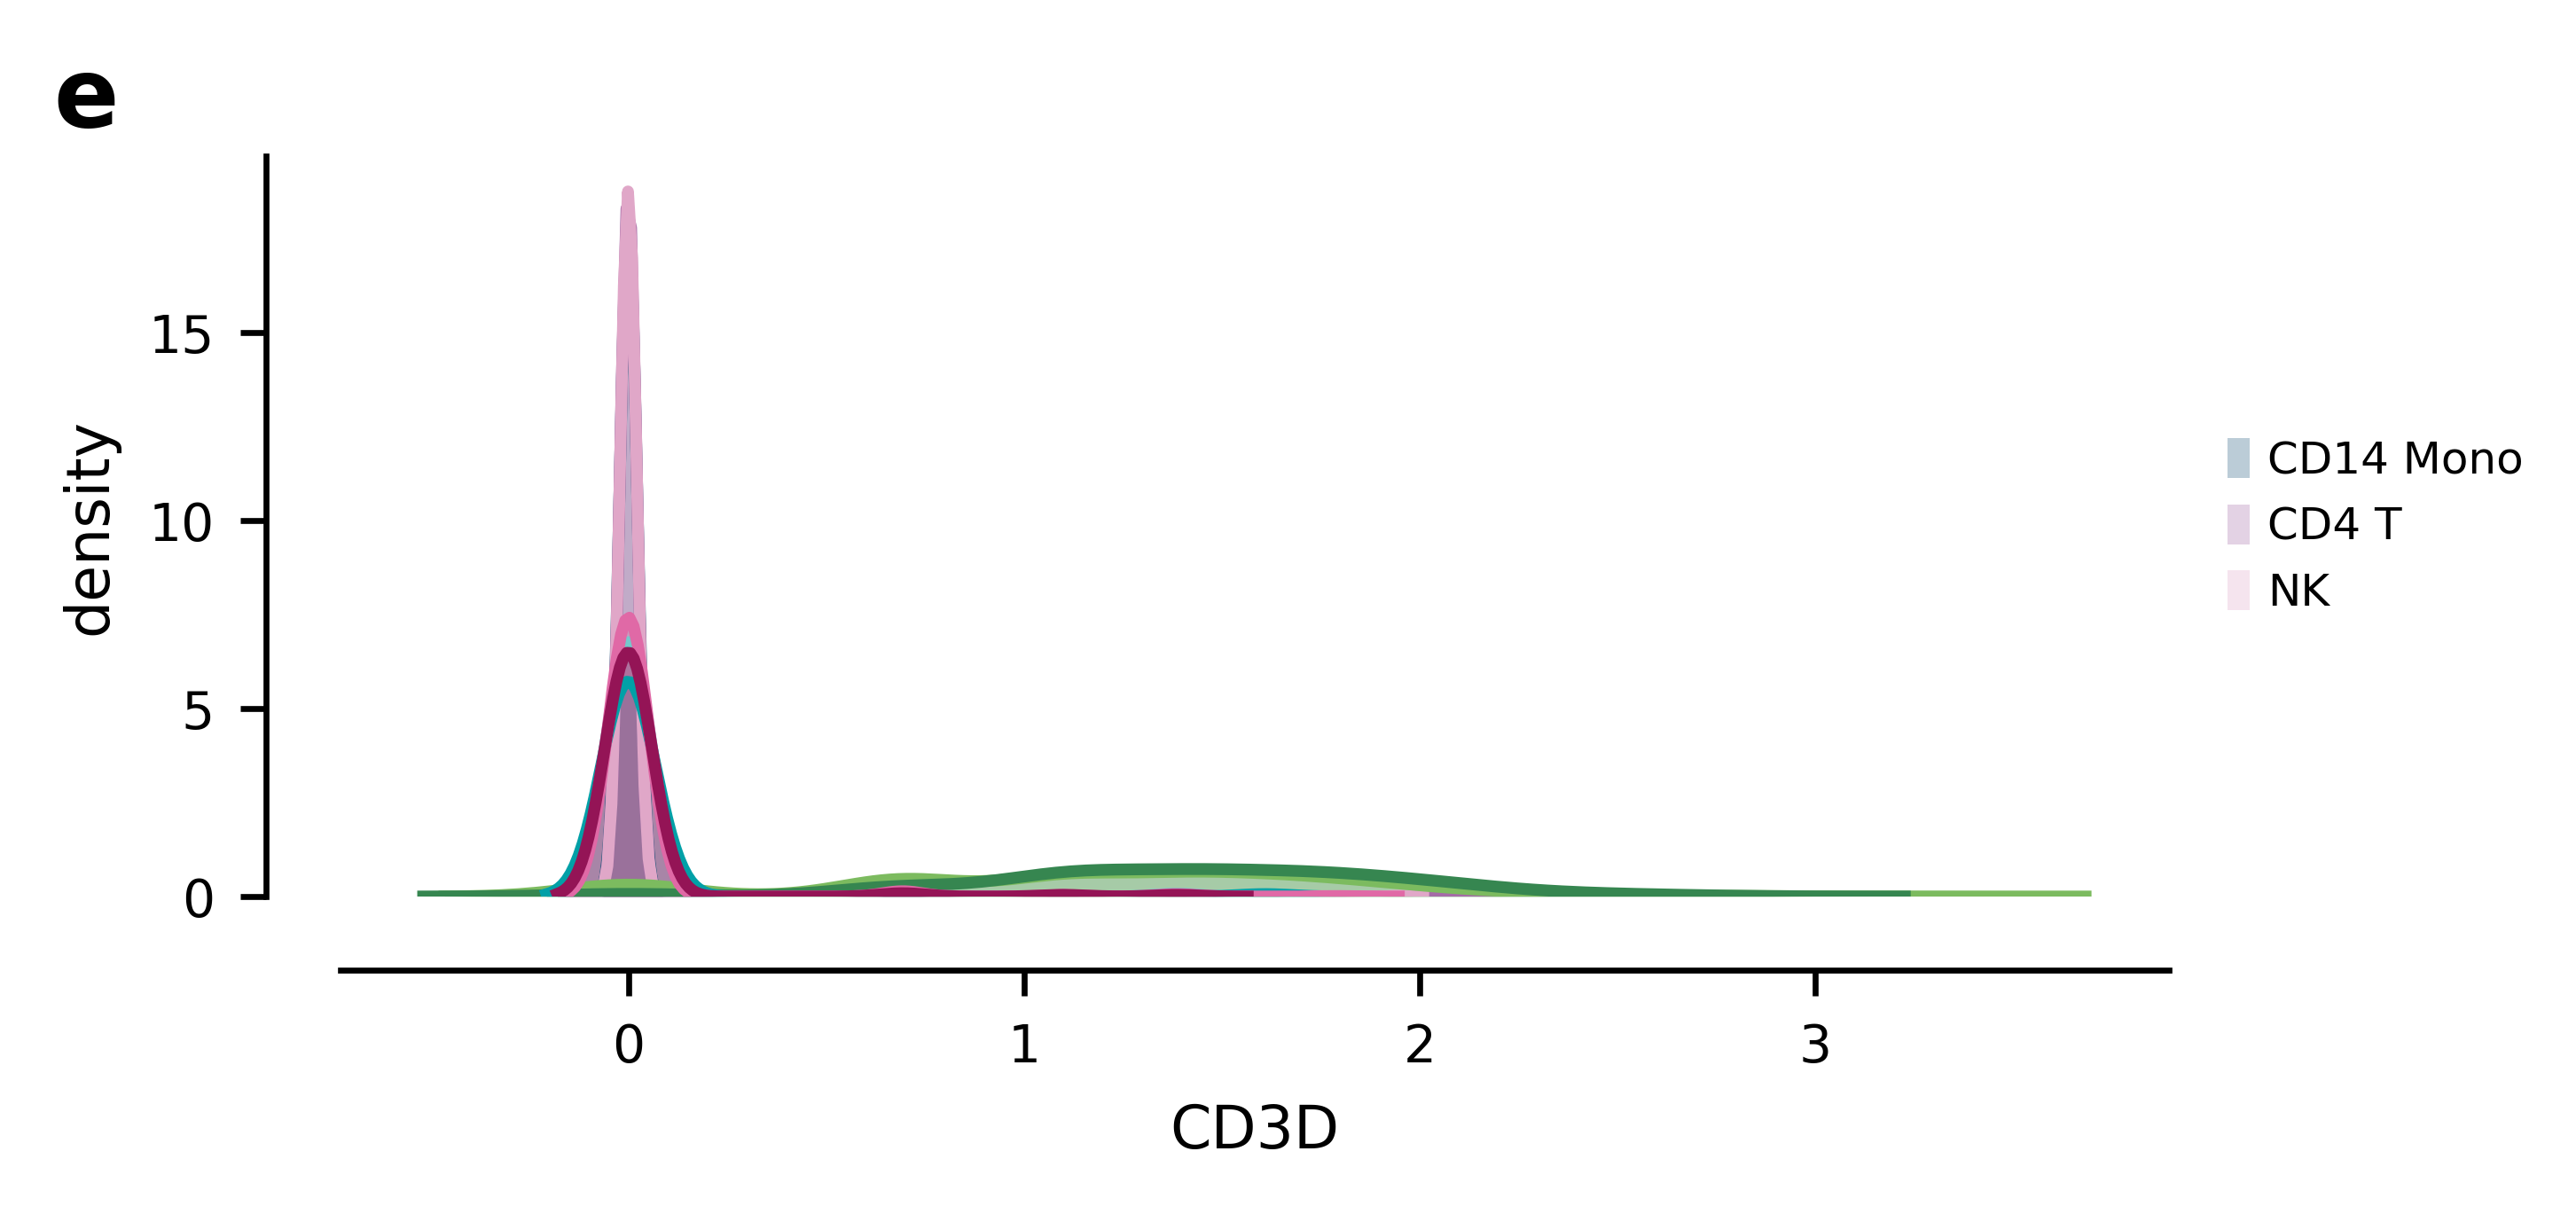

In [20]:
fig, ax = ov.pl.figure(120, 55, axes=True)
ov.pl.kdeplot(main, 'CD3D', hue='cell_type', ax=ax, fill=True, fontsize=7,
              legend=False)
ov.pl.add_panel_label(ax, 'e', dx=-30, dy=4)
ov.pl.take_legend_out(ax, loc='right', fontsize=6,
                      handles=ax.collections[:3],
                      labels=list(main['cell_type'].unique()[:3]))
plt.show()

### Figure 1, assembled and exported

Putting it together with the omics panels from the earlier sections. The whole
composition is one figure object, so it exports in one call — and
`ov.pl.savefig` keeps the text as **text** in the SVG, which is what makes the
labels editable in Illustrator or Inkscape later.

Note `bbox_inches=None`: the default `'tight'` crops to the drawn content,
which is convenient but silently changes the width you asked for. When a
journal specifies 183 mm, pass `None` and keep it.

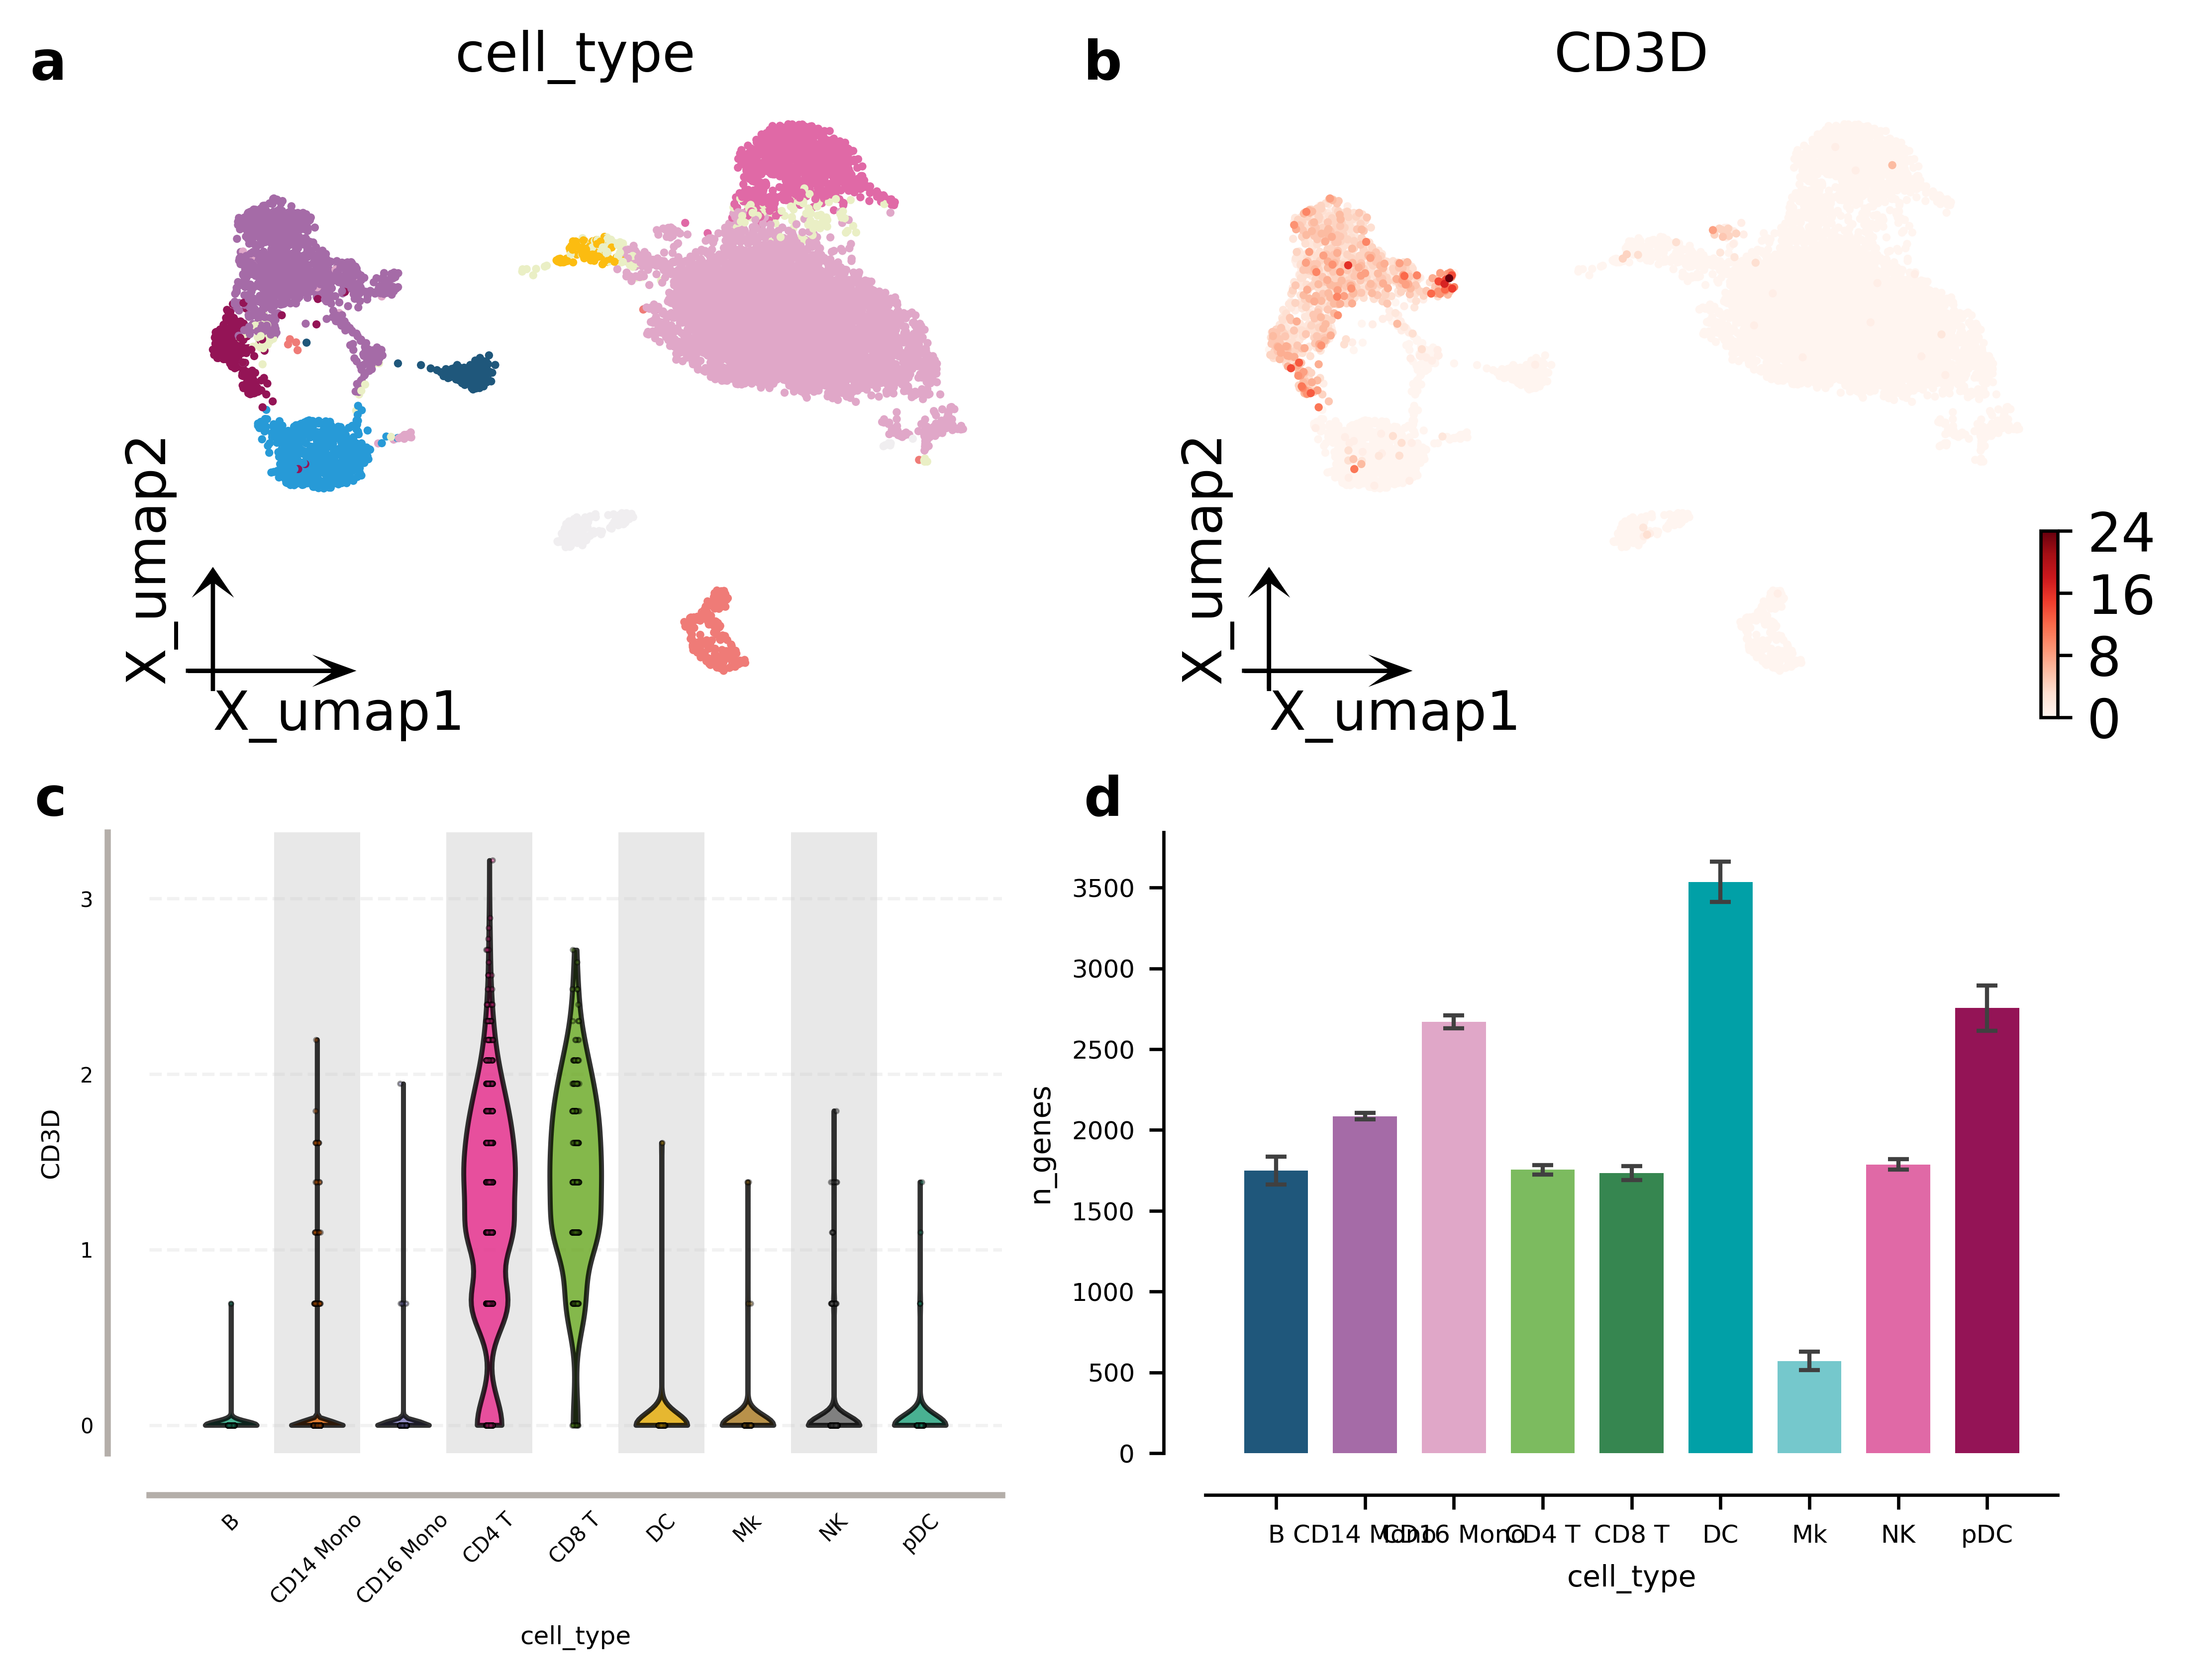

In [21]:
fig, ax = ov.pl.multipanel('AB\nCD', width='nature-double', height=140)
ov.pl.embedding(adata, basis='X_umap', color='cell_type', frameon='small',
                legend_loc=None, show=False, ax=ax['a'])
ov.pl.embedding(adata, basis='X_umap', color='CD3D', cmap='Reds',
                frameon='small', show=False, ax=ax['b'])
ov.pl.violin(main, keys='CD3D', groupby='cell_type', ax=ax['c'], rotation=45, fontsize=6)
ov.pl.barplot(main, 'cell_type', 'n_genes', ax=ax['d'], rotation=45, fontsize=6,
              errorbar='ci')
plt.show()

In [22]:
paths = ov.pl.savefig(fig, 'figures/plotting/figure1',
                      formats=['pdf', 'svg', 'png'], dpi=300,
                      bbox_inches=None)
svg = open('figures/plotting/figure1.svg').read()
print('width kept       :', (fig.get_size_inches()[0] * 25.4).round(1), 'mm')
print('SVG has <text>   :', '<text' in svg)
print('a label is a str :', 'cell_type' in svg)

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 37 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'K', 'M', 'N', 'T', 'X', 'a', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 's', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 27, 37, 38, 39, 46, 48, 49, 55, 59, 66, 68, 69, 70, 71, 72, 74, 78, 79, 80, 81, 82, 83, 86, 87, 88, 92]
INFO:fontTools.subset:Cl

Saved: figures/plotting/figure1.pdf, figures/plotting/figure1.svg, figures/plotting/figure1.png
width kept       : 183.0 mm
SVG has <text>   : True
a label is a str : True


One difference from `cnsplots` worth knowing if you are coming from it: its
`multipanel` is a **flow** builder — you call `mp.panel('A', 70, 70)` and give
every panel its own pixel size, and panels wrap when they reach `max_width`.
`ov.pl.multipanel` is a **grid/mosaic** builder: the figure has one physical
size and the panels divide it, with `width_ratios` / `height_ratios` and
spanning for the uneven cases.

The grid model reproduces every layout in the cnsplots showcase (they are all
regular grids), composes with any function that accepts `ax=`, and stays a
plain matplotlib figure. What it does not express is "panel A is exactly
70 x 70 mm regardless of its neighbours" — if you need that, build the panel
with `ov.pl.figure` and place it with `fig.add_axes`.

## 9. A practical checklist before you finalize a figure

Before a figure enters a manuscript, verify the following:

1. **Biological meaning is clear**: the plot answers one question well.
2. **Category colors are stable**: the same cell type is not recolored in another panel.
3. **Colormap logic is correct**: sequential for abundance, diverging for signed contrasts.
4. **Text is readable**: labels are not oversized, but they also do not disappear after export.
5. **Panel geometry is consistent**: similar figures use similar figure sizes.
6. **Legends are under control**: present when needed, suppressed when redundant.
7. **Export is complete**: both `png` and `svg` are saved with `dpi=300`.
8. **The figure can stand alone**: title, axis labels, and color interpretation are understandable without code.

If a figure fails any of these checks, improve the figure before generating more figures.

## Summary

A good scientific figure in `omicverse` is not defined by complexity. It is defined by **consistency**, **semantic color usage**, **appropriate plot choice**, and **clean export**.

A useful working order is:

1. define global style
2. fix categorical palettes
3. choose the correct continuous colormap
4. make the overview plot
5. make the evidence plot
6. export in paired formats

Once you standardize these steps, your plotting workflow becomes faster, more reproducible, and much easier to maintain across a full project.